### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [1]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [2]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
fatal: destination path 'Machine-Learning' already exists and is not an empty directory.
Repository 'Machine-Learning' cloned successfully.


In [3]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [4]:
%cd Machine-Learning/Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


%ls

/content/Machine-Learning/Assignment4
mv: cannot stat 'kaggle.json': No such file or directory
challenges-in-representation-learning-facial-expression-recognition-challenge_data/
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
deep_pipeline_lr0.0001_bs128.pth
deep_pipeline_lr0.0001_bs32.pth
deep_pipeline_lr0.0005_bs128.pth
deep_pipeline_lr0.0005_bs32.pth
deep_pipeline_lr0.001_bs128.pth
deep_pipeline_lr0.001_bs32.pth
model_files/
pipeline_v_lr0.0001_bs128.pth
pipeline_v_lr0.0001_bs32.pth
pipeline_v_lr0.0005_bs128.pth
pipeline_v_lr0.0005_bs32.pth
pipeline_v_lr0.001_bs128.pth
pipeline_v_lr0.001_bs32.pth
pipeline_v_lr0.005_bs128.pth
pipeline_v_lr0.005_bs32.pth
pipeline_v_lr0.01_bs128.pth
pipeline_v_lr0.01_bs32.pth
README.md
resnet_pipeline_lr0.0001_bs128.pth
resnet_pipeline_lr0.0001_bs32.pth
resnet_pipeline_lr0.0005_bs128.pth
resnet_pipeline_lr0.0005_bs32.pth
resnet_pipeline_lr0.001_bs128.pth
resnet_pipeline_lr0.001_bs32.pth
resnet_val_lr0.0005_bs32.pth
wa

### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [16]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


### Unzip the Downloaded Data

In [6]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

replace ./challenges-in-representation-learning-facial-expression-recognition-challenge_data/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv
Data unzipped to ./challenges-in-representation-learning-facial-expression-recognition-challenge_data


### Change directory to Machine-Learning

In [7]:
# %cd Machine-Learning

## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


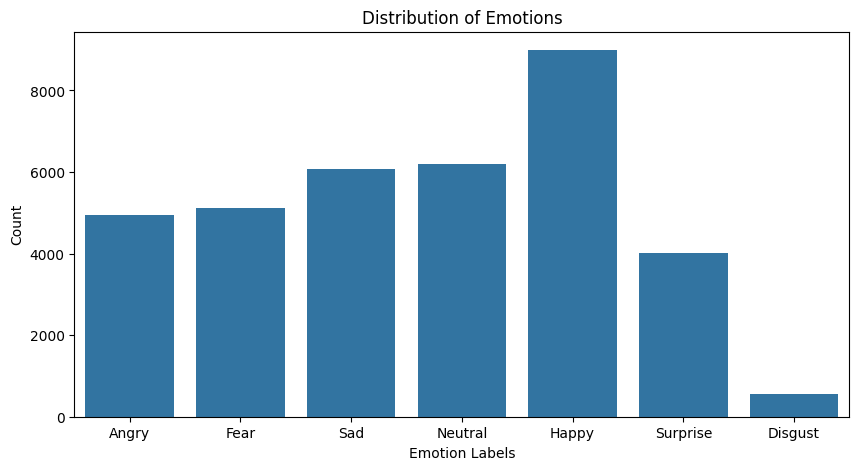

In [9]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


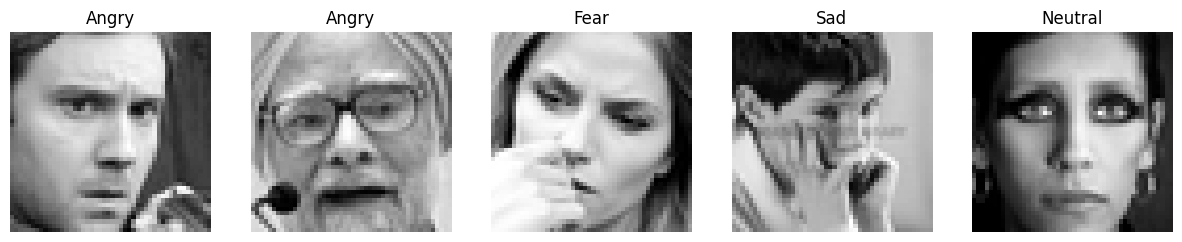

In [10]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


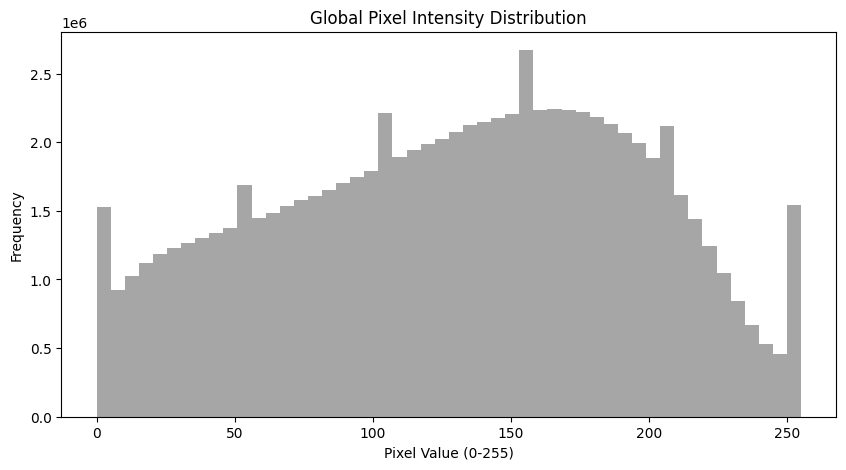

In [11]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract pixels and label
        pixels = self.df.iloc[idx][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        # Add channel dimension (H, W) -> (H, W, C) for transforms
        image = image[:, :, np.newaxis] / 255.0

        if self.transform:
            image = self.transform(image)

        return image, label

# Define basic transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Note: We can add augmentation here later
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe based on ' Usage'
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with {len(train_dataset)} training and {len(val_dataset)} validation samples.")

DataLoaders created with 28709 training and 3589 validation samples.


## 3. Model Development
### 3.1 Baseline CNN
We define a simple CNN architecture to start our experiments.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()
        # Convolutional Layer 1: 1 input channel (grayscale), 32 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Convolutional Layer 2: 32 input, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After two 2x2 pools, 48x48 becomes 12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 12 * 12)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN(num_classes=7).to(device)

print(f"Model initialized on device: {device}")

Model initialized on device: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

Create sweep with ID: 81delmpd
Sweep URL: https://wandb.ai/gbera23-free-university-of-tbilisi-/facial-expression-recognition/sweeps/81delmpd


wandb: Agent Starting Run: nzj5ndub with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.01_bs_32 | Epoch [1/5], Train Loss: 1.8373, Train Acc: 24.89%, Val Loss: 1.8180, Val Acc: 24.94%
Run: lr_0.01_bs_32 | Epoch [2/5], Train Loss: 1.8125, Train Acc: 25.13%, Val Loss: 1.8120, Val Acc: 24.94%
Run: lr_0.01_bs_32 | Epoch [3/5], Train Loss: 1.8119, Train Acc: 25.13%, Val Loss: 1.8124, Val Acc: 24.94%
Run: lr_0.01_bs_32 | Epoch [4/5], Train Loss: 1.8108, Train Acc: 25.13%, Val Loss: 1.8108, Val Acc: 24.94%
Run: lr_0.01_bs_32 | Epoch [5/5], Train Loss: 1.8114, Train Acc: 25.13%, Val Loss: 1.8114, Val Acc: 24.94%


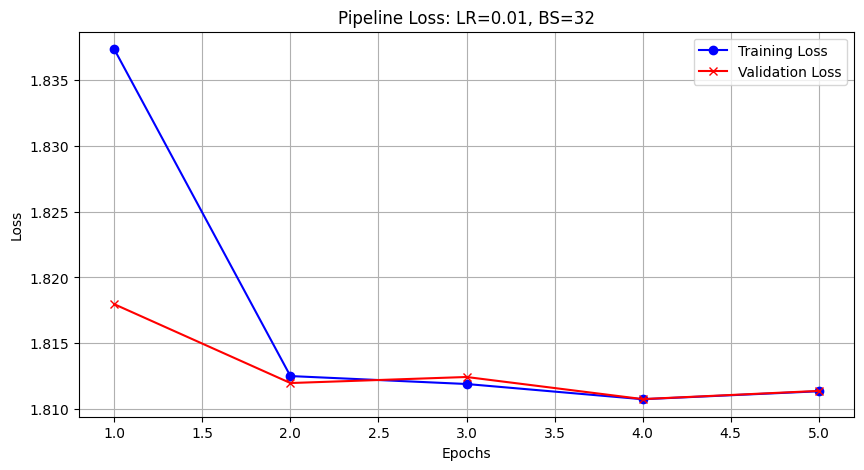

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.01_bs32.pth


epoch,▁▃▅▆█
train_accuracy,▁████
train_loss,█▁▁▁▁
val_accuracy,▁▁▁▁▁
val_loss,█▂▃▁▂
epoch,5
train_accuracy,25.13149
train_loss,1.81136
val_accuracy,24.93731
val_loss,1.81138


wandb: Agent Starting Run: 9q4guncj with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.005_bs_32 | Epoch [1/5], Train Loss: 1.8189, Train Acc: 25.09%, Val Loss: 1.8112, Val Acc: 24.94%
Run: lr_0.005_bs_32 | Epoch [2/5], Train Loss: 1.8130, Train Acc: 25.13%, Val Loss: 1.8110, Val Acc: 24.94%
Run: lr_0.005_bs_32 | Epoch [3/5], Train Loss: 1.8116, Train Acc: 25.13%, Val Loss: 1.8111, Val Acc: 24.94%
Run: lr_0.005_bs_32 | Epoch [4/5], Train Loss: 1.8118, Train Acc: 25.13%, Val Loss: 1.8112, Val Acc: 24.94%
Run: lr_0.005_bs_32 | Epoch [5/5], Train Loss: 1.8112, Train Acc: 25.13%, Val Loss: 1.8118, Val Acc: 24.94%


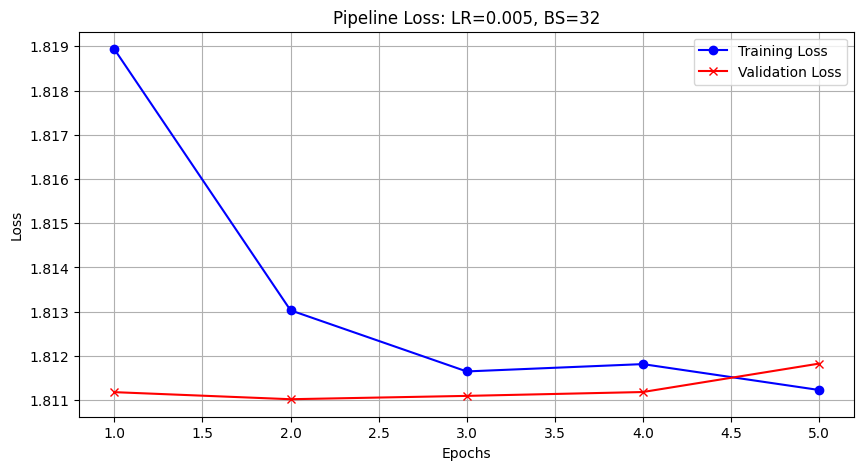

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.005_bs32.pth


epoch,▁▃▅▆█
train_accuracy,▁████
train_loss,█▃▁▂▁
val_accuracy,▁▁▁▁▁
val_loss,▂▁▂▂█
epoch,5
train_accuracy,25.13149
train_loss,1.81123
val_accuracy,24.93731
val_loss,1.81183


wandb: Agent Starting Run: tg6vpvvk with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.001_bs_32 | Epoch [1/5], Train Loss: 1.6316, Train Acc: 35.03%, Val Loss: 1.4639, Val Acc: 44.61%
Run: lr_0.001_bs_32 | Epoch [2/5], Train Loss: 1.4155, Train Acc: 45.85%, Val Loss: 1.3493, Val Acc: 47.53%
Run: lr_0.001_bs_32 | Epoch [3/5], Train Loss: 1.3213, Train Acc: 49.37%, Val Loss: 1.3077, Val Acc: 48.70%
Run: lr_0.001_bs_32 | Epoch [4/5], Train Loss: 1.2462, Train Acc: 52.26%, Val Loss: 1.2815, Val Acc: 50.38%
Run: lr_0.001_bs_32 | Epoch [5/5], Train Loss: 1.1798, Train Acc: 55.17%, Val Loss: 1.2651, Val Acc: 51.21%


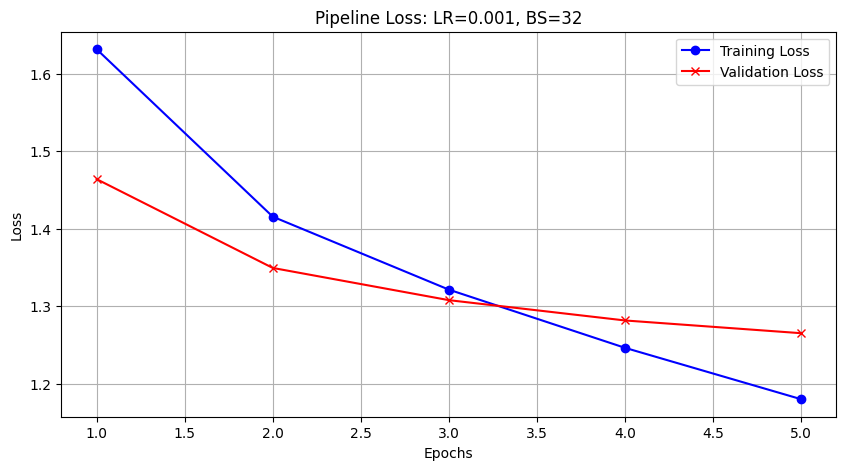

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.001_bs32.pth


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▄▅▇█
val_loss,█▄▃▂▁
epoch,5
train_accuracy,55.17434
train_loss,1.17984
val_accuracy,51.21204
val_loss,1.26505


wandb: Agent Starting Run: wpaa304g with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.0005_bs_32 | Epoch [1/5], Train Loss: 1.5937, Train Acc: 37.42%, Val Loss: 1.4446, Val Acc: 45.11%
Run: lr_0.0005_bs_32 | Epoch [2/5], Train Loss: 1.3875, Train Acc: 47.00%, Val Loss: 1.3261, Val Acc: 49.18%
Run: lr_0.0005_bs_32 | Epoch [3/5], Train Loss: 1.2829, Train Acc: 50.89%, Val Loss: 1.2771, Val Acc: 50.68%
Run: lr_0.0005_bs_32 | Epoch [4/5], Train Loss: 1.1987, Train Acc: 54.52%, Val Loss: 1.2671, Val Acc: 51.55%
Run: lr_0.0005_bs_32 | Epoch [5/5], Train Loss: 1.1061, Train Acc: 58.17%, Val Loss: 1.2271, Val Acc: 53.27%


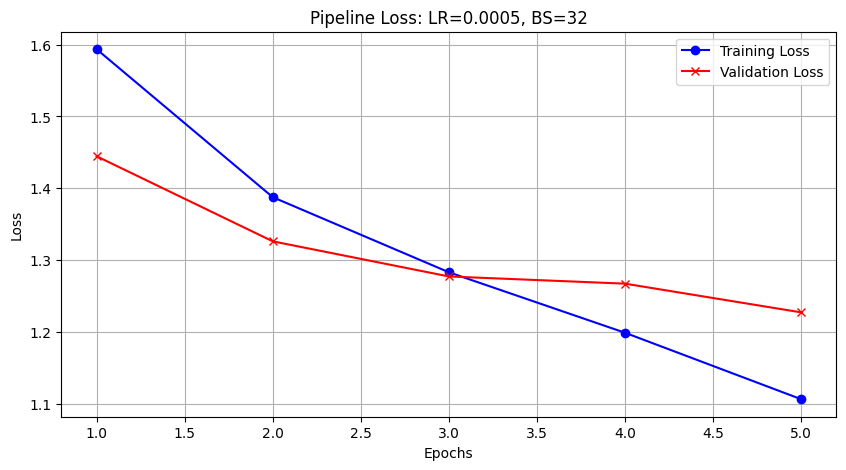

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0005_bs32.pth


epoch,▁▃▅▆█
train_accuracy,▁▄▆▇█
train_loss,█▅▄▂▁
val_accuracy,▁▄▆▇█
val_loss,█▄▃▂▁
epoch,5
train_accuracy,58.16991
train_loss,1.10612
val_accuracy,53.27389
val_loss,1.2271


wandb: Agent Starting Run: 2vqp7w0f with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.0001_bs_32 | Epoch [1/5], Train Loss: 1.7151, Train Acc: 31.04%, Val Loss: 1.6022, Val Acc: 37.87%
Run: lr_0.0001_bs_32 | Epoch [2/5], Train Loss: 1.5846, Train Acc: 38.63%, Val Loss: 1.5269, Val Acc: 41.49%
Run: lr_0.0001_bs_32 | Epoch [3/5], Train Loss: 1.5142, Train Acc: 41.95%, Val Loss: 1.4718, Val Acc: 44.78%
Run: lr_0.0001_bs_32 | Epoch [4/5], Train Loss: 1.4553, Train Acc: 44.30%, Val Loss: 1.4216, Val Acc: 45.89%
Run: lr_0.0001_bs_32 | Epoch [5/5], Train Loss: 1.4124, Train Acc: 46.26%, Val Loss: 1.3876, Val Acc: 47.73%


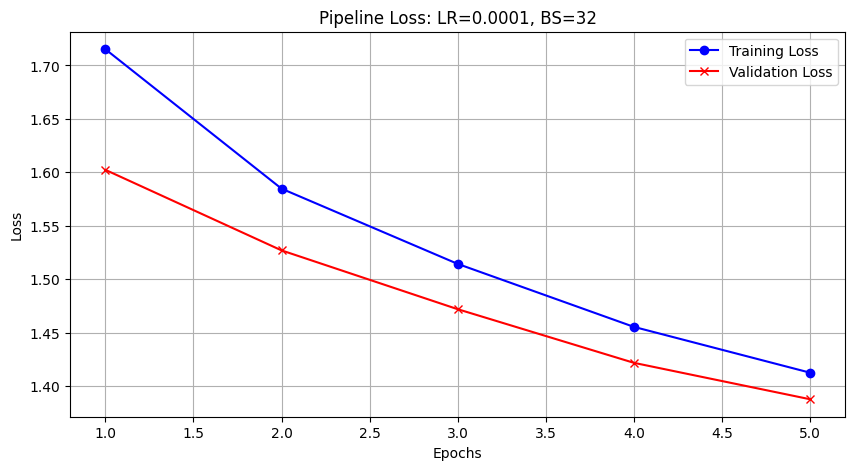

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0001_bs32.pth


epoch,▁▃▅▆█
train_accuracy,▁▄▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▄▆▇█
val_loss,█▆▄▂▁
epoch,5
train_accuracy,46.26075
train_loss,1.41243
val_accuracy,47.72917
val_loss,1.38756


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ybokdu2c with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.01_bs_128 | Epoch [1/5], Train Loss: 1.8893, Train Acc: 24.58%, Val Loss: 1.8074, Val Acc: 24.94%
Run: lr_0.01_bs_128 | Epoch [2/5], Train Loss: 1.8119, Train Acc: 25.13%, Val Loss: 1.8118, Val Acc: 24.94%
Run: lr_0.01_bs_128 | Epoch [3/5], Train Loss: 1.8118, Train Acc: 25.13%, Val Loss: 1.8080, Val Acc: 24.94%
Run: lr_0.01_bs_128 | Epoch [4/5], Train Loss: 1.8124, Train Acc: 25.13%, Val Loss: 1.8116, Val Acc: 24.94%
Run: lr_0.01_bs_128 | Epoch [5/5], Train Loss: 1.8107, Train Acc: 25.13%, Val Loss: 1.8096, Val Acc: 24.94%


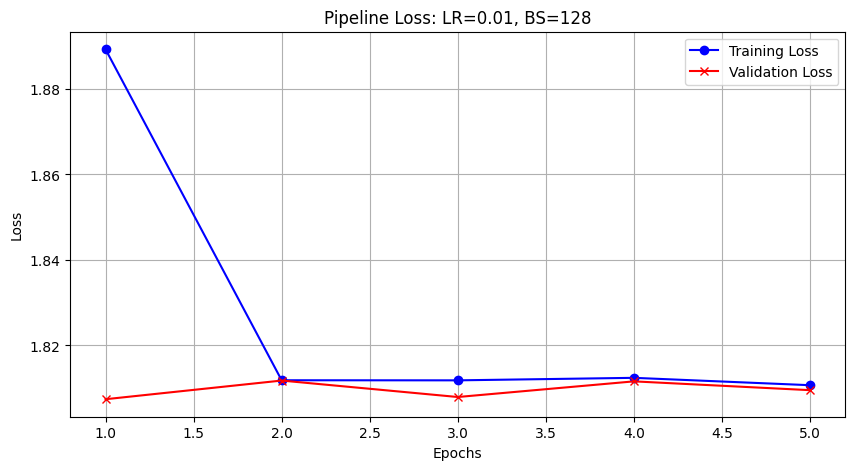

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.01_bs128.pth


epoch,▁▃▅▆█
train_accuracy,▁████
train_loss,█▁▁▁▁
val_accuracy,▁▁▁▁▁
val_loss,▁█▂█▄
epoch,5
train_accuracy,25.13149
train_loss,1.81072
val_accuracy,24.93731
val_loss,1.80955


wandb: Agent Starting Run: f64bx7x4 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.005_bs_128 | Epoch [1/5], Train Loss: 1.7065, Train Acc: 32.22%, Val Loss: 1.5247, Val Acc: 40.82%
Run: lr_0.005_bs_128 | Epoch [2/5], Train Loss: 1.5275, Train Acc: 40.33%, Val Loss: 1.4713, Val Acc: 41.99%
Run: lr_0.005_bs_128 | Epoch [3/5], Train Loss: 1.4591, Train Acc: 43.22%, Val Loss: 1.4277, Val Acc: 45.08%
Run: lr_0.005_bs_128 | Epoch [4/5], Train Loss: 1.4246, Train Acc: 44.56%, Val Loss: 1.4052, Val Acc: 45.17%
Run: lr_0.005_bs_128 | Epoch [5/5], Train Loss: 1.3994, Train Acc: 45.41%, Val Loss: 1.4064, Val Acc: 45.64%


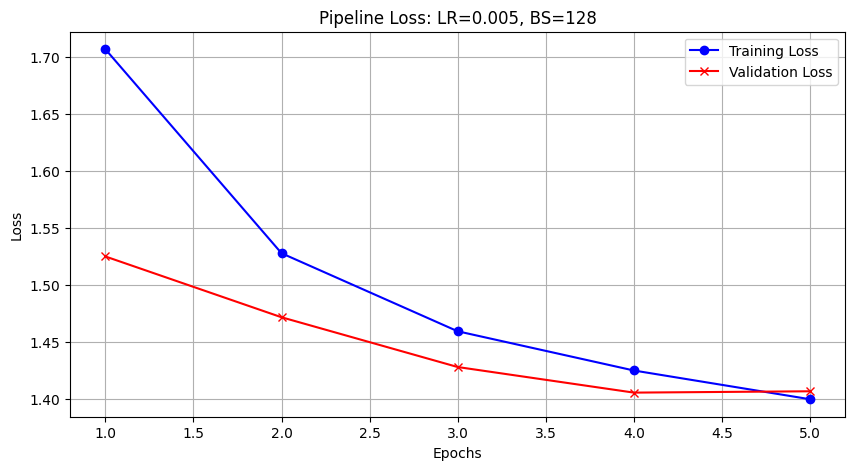

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.005_bs128.pth


epoch,▁▃▅▆█
train_accuracy,▁▅▇██
train_loss,█▄▂▂▁
val_accuracy,▁▃▇▇█
val_loss,█▅▂▁▁
epoch,5
train_accuracy,45.41085
train_loss,1.39942
val_accuracy,45.63945
val_loss,1.40639


wandb: Agent Starting Run: f1rxu9p0 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.001_bs_128 | Epoch [1/5], Train Loss: 1.6206, Train Acc: 36.15%, Val Loss: 1.4335, Val Acc: 44.44%
Run: lr_0.001_bs_128 | Epoch [2/5], Train Loss: 1.4037, Train Acc: 45.80%, Val Loss: 1.3611, Val Acc: 47.76%
Run: lr_0.001_bs_128 | Epoch [3/5], Train Loss: 1.2931, Train Acc: 50.85%, Val Loss: 1.2830, Val Acc: 51.04%
Run: lr_0.001_bs_128 | Epoch [4/5], Train Loss: 1.1953, Train Acc: 54.89%, Val Loss: 1.2353, Val Acc: 52.86%
Run: lr_0.001_bs_128 | Epoch [5/5], Train Loss: 1.1035, Train Acc: 58.39%, Val Loss: 1.2274, Val Acc: 53.27%


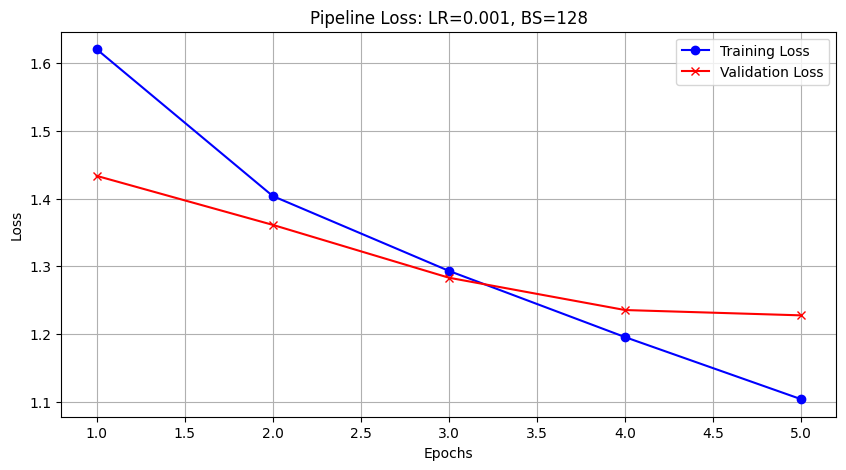

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.001_bs128.pth


epoch,▁▃▅▆█
train_accuracy,▁▄▆▇█
train_loss,█▅▄▂▁
val_accuracy,▁▄▆██
val_loss,█▆▃▁▁
epoch,5
train_accuracy,58.38587
train_loss,1.10354
val_accuracy,53.27389
val_loss,1.22743


wandb: Agent Starting Run: 84uxxdy2 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.0005_bs_128 | Epoch [1/5], Train Loss: 1.6489, Train Acc: 34.65%, Val Loss: 1.5046, Val Acc: 41.71%
Run: lr_0.0005_bs_128 | Epoch [2/5], Train Loss: 1.4737, Train Acc: 43.69%, Val Loss: 1.4108, Val Acc: 46.36%
Run: lr_0.0005_bs_128 | Epoch [3/5], Train Loss: 1.3777, Train Acc: 47.55%, Val Loss: 1.3525, Val Acc: 47.98%
Run: lr_0.0005_bs_128 | Epoch [4/5], Train Loss: 1.3116, Train Acc: 50.14%, Val Loss: 1.3029, Val Acc: 49.37%
Run: lr_0.0005_bs_128 | Epoch [5/5], Train Loss: 1.2478, Train Acc: 52.62%, Val Loss: 1.2808, Val Acc: 50.63%


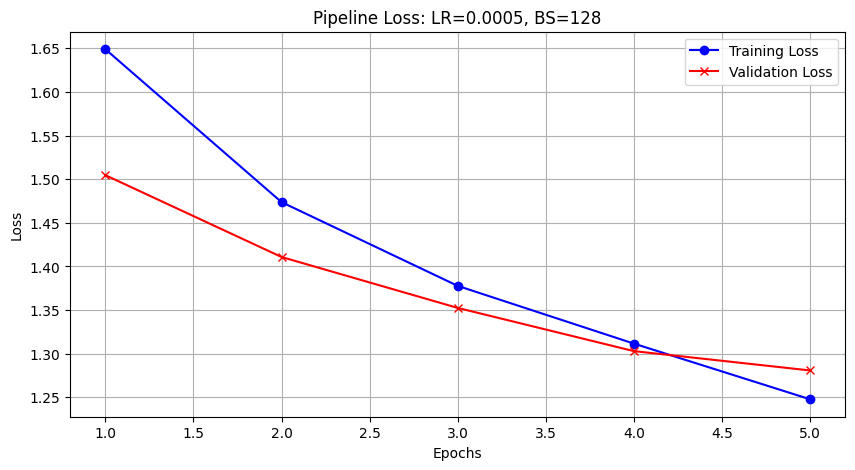

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0005_bs128.pth


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▅▆▇█
val_loss,█▅▃▂▁
epoch,5
train_accuracy,52.62113
train_loss,1.24781
val_accuracy,50.62692
val_loss,1.28079


wandb: Agent Starting Run: 3bx71v4k with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: lr_0.0001_bs_128 | Epoch [1/5], Train Loss: 1.7407, Train Acc: 29.62%, Val Loss: 1.6300, Val Acc: 36.95%
Run: lr_0.0001_bs_128 | Epoch [2/5], Train Loss: 1.6251, Train Acc: 36.50%, Val Loss: 1.5698, Val Acc: 39.12%
Run: lr_0.0001_bs_128 | Epoch [3/5], Train Loss: 1.5744, Train Acc: 39.15%, Val Loss: 1.5391, Val Acc: 40.87%
Run: lr_0.0001_bs_128 | Epoch [4/5], Train Loss: 1.5374, Train Acc: 41.12%, Val Loss: 1.5047, Val Acc: 42.44%
Run: lr_0.0001_bs_128 | Epoch [5/5], Train Loss: 1.5081, Train Acc: 42.19%, Val Loss: 1.4735, Val Acc: 42.77%


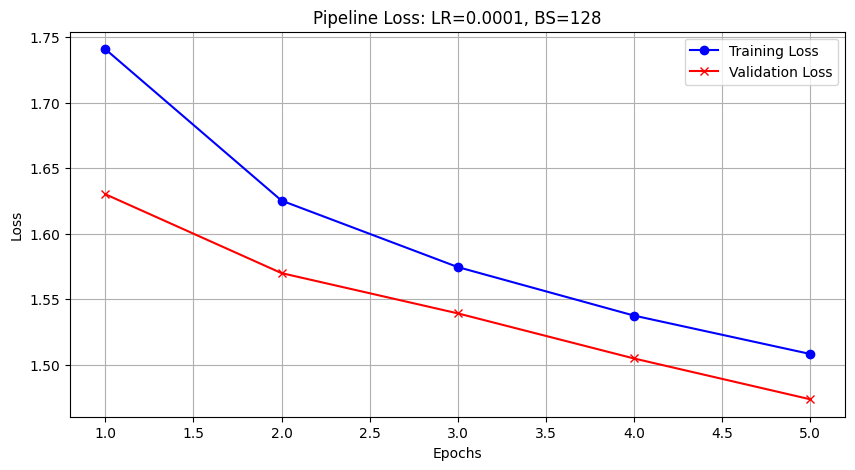

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0001_bs128.pth


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▄▆██
val_loss,█▅▄▂▁
epoch,5
train_accuracy,42.18886
train_loss,1.5081
val_accuracy,42.76957
val_loss,1.47351


In [15]:
import matplotlib.pyplot as plt
import wandb
import torch
import torch.nn as nn

# Ensure the pipeline class is defined for the sweep
class FERPipeline(nn.Module):
    def __init__(self, model, transform):
        super(FERPipeline, self).__init__()
        self.model = model
        self.transform = transform

    def forward(self, x):
        return self.model(x)

def train_sweep():
    with wandb.init() as run:
        config = run.config
        run.name = f"lr_{config.learning_rate}_bs_{config.batch_size}"

        # 1. Initialize Model & Pipeline
        sweep_model = BaselineCNN(num_classes=7).to(device)
        sweep_optimizer = optim.Adam(sweep_model.parameters(), lr=config.learning_rate)
        sweep_train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        sweep_val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

        # Create the pipeline instance for this run
        current_pipeline = FERPipeline(sweep_model, val_transform)

        loss_history = []
        val_loss_history = []
        num_epochs = 5

        # 2. Training Loop
        for epoch in range(num_epochs):
            # Training
            sweep_model.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            for images, labels in sweep_train_loader:
                images, labels = images.to(device), labels.to(device)
                sweep_optimizer.zero_grad()
                outputs = sweep_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                sweep_optimizer.step()

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

            avg_train_loss = running_loss / len(sweep_train_loader)
            train_accuracy = 100 * correct_train / total_train

            # Validation
            sweep_model.eval()
            val_loss = 0.0
            correct_val = 0
            total_val = 0
            with torch.no_grad():
                for images, labels in sweep_val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = sweep_model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    total_val += labels.size(0)
                    correct_val += (predicted == labels).sum().item()

            avg_val_loss = val_loss / len(sweep_val_loader)
            val_accuracy = 100 * correct_val / total_val

            loss_history.append(avg_train_loss)
            val_loss_history.append(avg_val_loss)
            wandb.log({"epoch": epoch + 1, "train_loss": avg_train_loss, "train_accuracy": train_accuracy, "val_loss": avg_val_loss, "val_accuracy": val_accuracy})
            print(f"Run: {run.name} | Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        # 3. Visualization
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='b', label='Training Loss')
        plt.plot(range(1, num_epochs + 1), val_loss_history, marker='x', color='r', label='Validation Loss')
        plt.title(f"Pipeline Loss: LR={config.learning_rate}, BS={config.batch_size}")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 4. Save as Pipeline Version
        model_filename = f"pipeline_v_lr{config.learning_rate}_bs{config.batch_size}.pth"
        torch.save(current_pipeline.state_dict(), model_filename)
        wandb.save(model_filename)
        print(f"Logged and saved pipeline version: {model_filename}")

# Sweep configuration
sweep_config = {
    'method': 'grid',
    'metric': {'name': 'val_loss', 'goal': 'minimize'},
    'parameters': {
        'learning_rate': {"values": [0.01, 0.005, 0.001, 0.0005, 0.0001]},
        'batch_size': {"values": [32, 128]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")
wandb.agent(sweep_id, function=train_sweep, count=10)
